In [1]:
# specify a PYFILES path that contains the folder LFEAnalysis with this package
PYFILES='/Users/jessicahawthorne/PYFILES'

# and specify a data directory that contains all the LFE data
data_directory='/Users/jessicahawthorne/DATA/LFEAnalysis'

### Notebook 7: Stacking by group

We now have codes to group LFEs and look at the stacks from various groups.  This notebook summarises those codes.

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(PYFILES)
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

### 1. Load and prepare the data

As usual, we first read in detections and the data.

In [3]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfeanalyse(fnum=156,catalog='Bostock',region='Cascadia',data_directory=data_directory)

# and read the relevant detections
lf.read_detection_info()

# load the data
lf.read_data()

In [4]:
# normalise the seismograms
lf.normalize_data(single_norm=False)

# we may first need to discard any LFE intervals that contain NaNs, 
# as these will disrupt the filtering
lf.discard_data_with_nans()

# and bandpass filter
# we can filter the intervals with a 2-pass (non-causal) butterworth filter
# let's choose corners of 1 and 10 Hz
lf.filter_data(flm=[1,10])

### 2. Group events by time

Next, we want to identify the slow slip events and group the LFEs in this family by their time in the event.

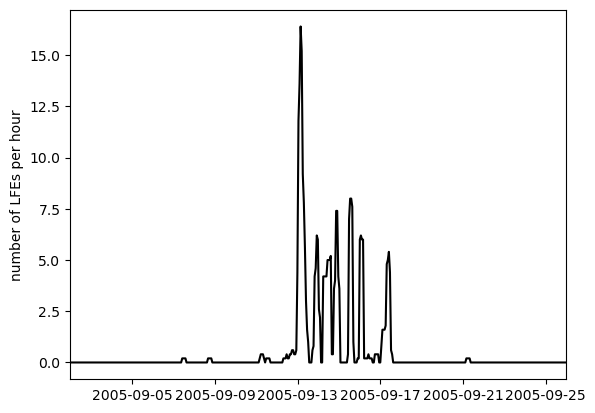

In [5]:
# identify the times of large SSEs
lf.identify_sse_times(n_events=10)

# here, compute the number of LFEs per 5-hour period
lf.compute_lfe_rates(bin_duration=5*3600)

plt.plot([tm.datetime for tm in lf.tcent],lf.lferate,color='black',marker='none',linestyle='-')
plt.xlim(lf.sse_tlms[2,:]);
plt.ylabel('number of LFEs per hour');

In [6]:
# to do so, we first determine a family "start time": 
# here the time when the LFE rate reaches half the maximum LFE rate
lf.select_start_times(start_rate=0.5)

# and then group the events by time since the start time
# here we have two groups: 0-0.75 days since the start time and 0.75-3 days since the start time
lf.group_events_bytime(tsplits=[0,0.75,3])

# we now have a dictionary 
print('The groups are ',list(lf.groups.keys()))

# here there are two groups: 'early' and 'late'
# the integers listed are the indices of the events in each group, 
# so the times of the first 10 LFEs in the early group are
print('The indices of the first 10 LFEs in the early group are\n',lf.groups['early'][0:10])
print('\nThe times of the first 10 LFEs in the early group are\n',lf.tms[lf.groups['early'][0:10]])

The groups are  ['early', 'late']
The indices of the first 10 LFEs in the early group are
 [ 4  5  6  7  8  9 10 11 12 13]

The times of the first 10 LFEs in the early group are
 [UTCDateTime(2003, 3, 4, 18, 37, 13, 25000)
 UTCDateTime(2003, 3, 4, 19, 10, 57, 650000)
 UTCDateTime(2003, 3, 4, 19, 15, 8, 850000)
 UTCDateTime(2003, 3, 4, 19, 42, 44, 425000)
 UTCDateTime(2003, 3, 4, 19, 53, 38, 350000)
 UTCDateTime(2003, 3, 4, 19, 59, 34, 100000)
 UTCDateTime(2003, 3, 4, 20, 1, 25, 625000)
 UTCDateTime(2003, 3, 4, 20, 2, 34, 175000)
 UTCDateTime(2003, 3, 4, 20, 18, 0, 200000)
 UTCDateTime(2003, 3, 4, 20, 19, 23, 225000)]


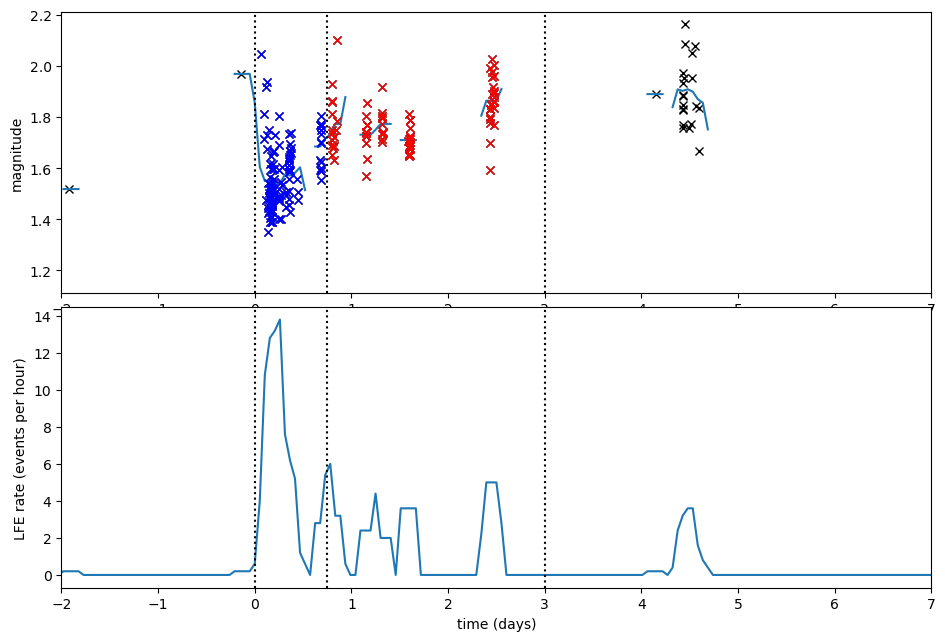

In [7]:
# it may be useful to plot the LFE properties and the LFE rate through time during an SSE
lf.plot_rate(iev=2003)

### 3. Stack

Now we can go ahead and make stacks.

In [8]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_stacking.py:473: RuntimeWarning: invalid value encountered in multiply
  self.grpstkb[ky][idi]=np.ndarray([nvl,Nboot])*float('nan')
/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_stacking.py:476: RuntimeWarning: invalid value encountered in multiply
  self.totstkb[idi]=np.ndarray([nvl,Nboot])*float('nan')


In [9]:
print('The grouped stacks are saved in a dictionary lf.grpstk, with keys ',lf.grpstk.keys())
print('\nlf.grpstk[\'early\'] contains',lf.grpstk['early'])

The grouped stacks are saved in a dictionary lf.grpstk, with keys  dict_keys(['early', 'late'])

lf.grpstk['early'] contains 27 Trace(s) in Stream:

.B926..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
...
(25 other traces)
...
.YOUB..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


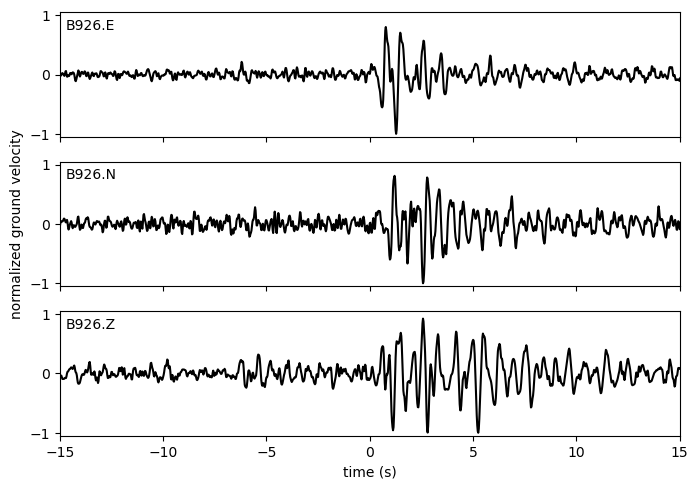

In [10]:
# we can plot the stack of all LFEs at station B926
p=lf.plot_stacks(stype='all',stn='B926')

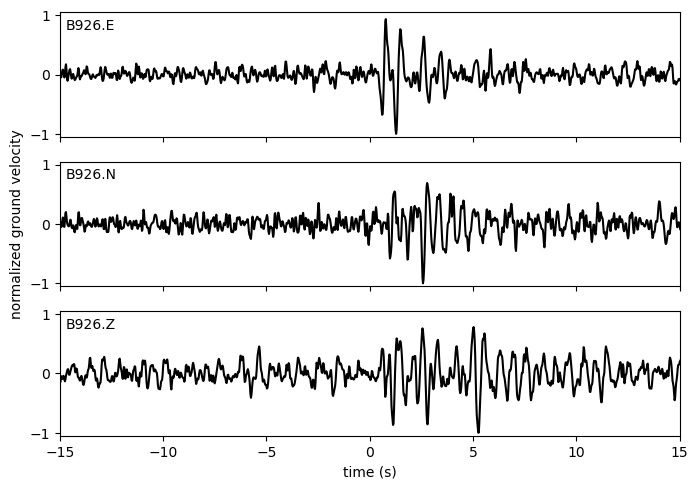

In [11]:
# we can look at the stack for one group
p=lf.plot_stacks(stype='early',Ns=1,stn='B926')

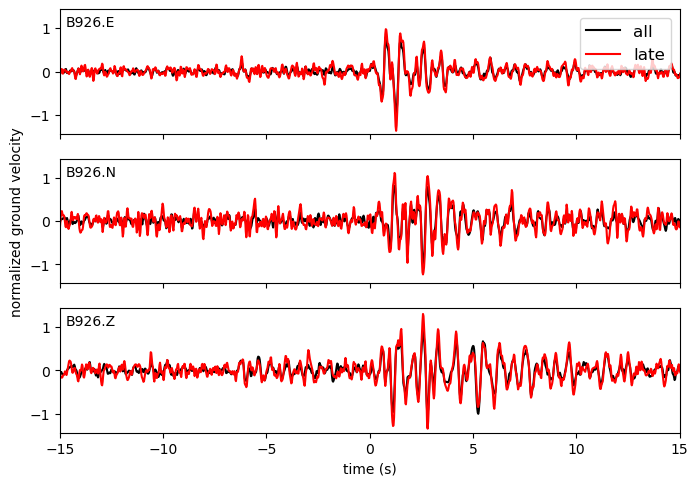

In [12]:
# and we could compare some of the stacks
p=lf.plot_stacks(stype='all',Ns=1,stn='B926',morestacks=['late'])

### 4. Note bootstrapped stacks

It may be useful to note that there are bootstrapped versions of the grouped stacks as well as bootstrapped versions of the total stack.

Stack with all events is in lf.totstk:  .SHVB..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

There are bootstrapped stacks including subsets of all events in lf.totstkb:  (3200, 30)


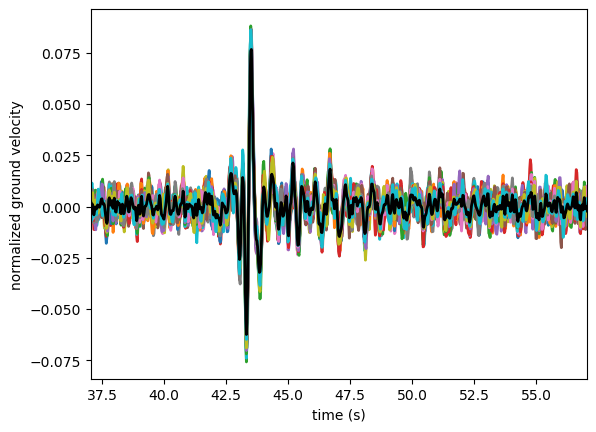

In [13]:
# let's look at the bootstrapped stacks for one station with good SNR
stn=np.random.choice(lf.stns_stack,1)[0]
# on the east component
chn='E'

# the trace with all the events
tr=lf.totstk.select(channel=chn,station=stn)[0]
print('Stack with all events is in lf.totstk: ',tr)

# the bootstrapped stacks
stkb=lf.totstkb['.'.join([stn,chn])]
print('\nThere are bootstrapped stacks including subsets of all events in lf.totstkb: ',stkb.shape)

plt.plot(tr.times(),stkb,linewidth=2,label='bootstrapped');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');

Stack with all events is in lf.grpstk:  .SHVB..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

There are bootstrapped stacks including subsets of the early events in lf.grpstkb['early']:  (3200, 30)


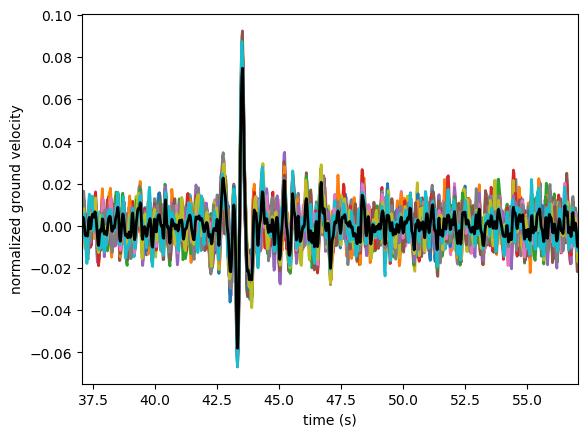

In [14]:
# the trace with all the events in the early group
tr=lf.grpstk['early'].select(channel=chn,station=stn)[0]
print('Stack with all events is in lf.grpstk: ',tr)

# the bootstrapped stacks
stkb=lf.grpstkb['early']['.'.join([stn,chn])]
print('\nThere are bootstrapped stacks including subsets of the early events in lf.grpstkb[\'early\']: ',stkb.shape)

plt.plot(tr.times(),stkb,linewidth=2,label='bootstrapped');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');